In [1]:
import pandas as pd
import numpy as np
from utils.plot_utils import plot_results


# read data in /battery_sizing_cfa/datasets/portugal.pk
data = pd.read_pickle("datasets/portugal/portugal.pk")

<Axes: >

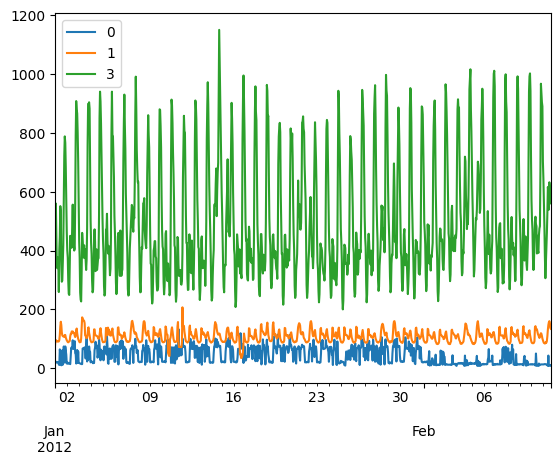

In [2]:
data.iloc[:1000, [0, 1, 3]].plot()

In [6]:
from scipy.optimize import differential_evolution
from battery_sizing_cfa.optimizers.deterministic_sizing import optimize_pv_battery
from battery_sizing_cfa.optimizers.rbc_sizing import  rbc_opt_fun

N = 14*24  # Use a multiple of 24 for full days
L = data.iloc[:N, 0].values  # Load and PV generation data
PV_base = np.maximum(0, np.sin(np.pi*(np.arange(N)/12 - 0.5)))           # MW
price = np.array([40. if (t%24) in range(18,24) else 20. for t in range(N)])  # $/MWh
export_price = np.ones(N)*0.1
Delta_t = 1.0

specs = {'c_PV_kw': 200.0,
         'c_bat_E_kwh': 120.0,
         'c_bat_P_kw': 50.0,
         'eta_ch': 0.95,
         'eta_dis': 0.95,
         'cyclic_SOC': True,
         'peak_tariff_per_MW_period': 100.0,
         'peak_period_steps': 24,
         'discount_rate': 0.06,
         'lifetime_years': 15,
         'replicate_periods': 26,
         'Delta_t':Delta_t,
         'soc_min':0,
         'soc_max':1,
         'soc_start':0.5,
         'energy_ratio':0.5
         }

initial_guess = [2, 0, 80, 0.2]  # Initial guess for [x_pv, E_bat_kWh, p_threshold, soc_min_price]
bounds = [(0, 600), (0, 600), (0, 100), (0, 1)]  # Bounds for each parameter

result = differential_evolution(
    rbc_opt_fun,
    bounds,
    args=(L, PV_base, price, export_price, specs),
    init='random',
    strategy='best1bin',
    maxiter=100,
    popsize=15,
    tol=0.01,
    polish=False
)


print("Optimized parameters (x_pv, E_bat_kWh, p_threshold, soc_min_price):", result.x)
print("Minimum LCOE from RBC optimization [$ / MWh]:", result.fun)

# re-simulate under optimal parameters
from battery_sizing_cfa.optimizers.parametric_rbc import rbc
price_high = price == max(price)
soc, p_batt, p_grid = rbc(p_tot=L - result['x'][0] * PV_base,  # net load is total consumption
                            price_high=price_high,
                            capacity_kwh=float(result['x'][1]), # Use kWh directly
                            soc_min_price_fun=np.array(result['x'][[3]]),
                            p_threshold_fun=np.array(result['x'][[2]]),
                            p_charge_max=float(result['x'][1]*0.5), # Use kW directly
                            p_discharge_max=float(result['x'][1]*0.5), # Use kW directly
                            eta_ch=specs['eta_ch'], eta_dis=specs['eta_dis'],
                            dt_hours=specs['Delta_t'],
                            soc_start=specs['soc_start'],
                            soc_min=specs['soc_min'],
                            soc_max=specs['soc_max'])

plot_results(result.x[0], result.x[1], p_batt, soc*result.x[1], PV_base, L, price)

Optimized parameters (x_pv, E_bat_kWh, p_threshold, soc_min_price): [117.84597578 146.53451422  38.48868817   0.34730315]
Minimum LCOE from RBC optimization [$ / MWh]: 26.416207182696844


In [4]:
from battery_sizing_cfa.optimizers.deterministic_sizing import optimize_pv_battery
res = optimize_pv_battery(
    L=L, PV_base=PV_base, price=price, export_price=export_price,
    solver_options={"time_limit": 120, "threads": 2}, **specs
)

print("Solver:", res["solver"], "| Termination:", res["termination"])
print("LCOE [$ / MWh]:", round(res["LCOE_$/MWh"], 2)) # Keep LCOE in $/MWh as it is a standard metric
print("x_pv:", round(res["x_pv"],3), "E_bat [kWh]:", round(res["E_bat_kWh"],2), "P_bat_max [kW]:", round(res["P_bat_max_kW"],2))
if "period_peaks_MW" in res: # Keep period_peaks_MW as it is used for the tariff
    print("Daily peak import [MW]:", np.round(res["period_peaks_MW"], 2))

Solver: appsi_highs | Termination: TerminationCondition.optimal
LCOE [$ / MWh]: 24.85
x_pv: 111.069 E_bat [kWh]: 171.28 P_bat_max [kW]: 85.64
Daily peak import [MW]: [0.02 0.02 0.03 0.03 0.06 0.05 0.04 0.03 0.04 0.03 0.05 0.04 0.05 0.04]


In [5]:

plot_results(res['x_pv'], res["E_bat_kWh"], res['series']['P_ch_kW'] -res['series']['P_dis_kW'], res['series']['SOC_kWh'], PV_base, L, price)